# SpectralNHITS — clasificación con NHITS multi-stack

Dual-head global/local sobre curvas binned (impar/par) sin coeficientes wavelet en entrada.
Cada cabeza aplica **varios stacks NHITS** (descomposición espectral aprendida, análoga al starlet del proyecto).
El clasificador fusiona las salidas **por bloque** de cada curva y vista.

## Librerias

In [1]:
from typing import Tuple
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd
from lib.b3_numpy import load_npz, load_index, level0_sample_arrays
from lib.spectral_nhits import SpectralNHITS

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Dispositivo: {device} ({torch.cuda.get_device_name(0)})")
else:
    device = torch.device("cpu")
    print("Dispositivo: cpu (sin GPU CUDA/ROCm)")


Dispositivo: cuda (AMD Radeon RX 9070 XT)


## Arquitectura del modelo

`SpectralNHITS` (`lib/spectral_nhits.py`) sigue la API de stacks de NHITS:

| Parámetro | Rol (análogo wavelet) |
|-----------|------------------------|
| `n_stacks` | Número de bandas de frecuencia |
| `n_blocks` | Bloques por stack (capacidad dentro de cada banda) |
| `n_pool_kernel_size` | Escala temporal / suavizado de entrada |
| `n_freq_downsample` | Expresividad de la interpolación de salida |
| `feature_mode="per_block"` | El clasificador recibe una feature por bloque (no solo la suma final) |

Por defecto: **4 stacks** en global y local. Cambiar `N_STACKS = 3` para el experimento alternativo.

In [47]:
# Definición en lib/spectral_nhits.py — ver stack_summary() tras instanciar el modelo

## Cargado de datos

In [2]:
NPZ_DIR = Path("all_data_2025_B3_npz")
index_df = load_index(NPZ_DIR)
print(f"Muestras exportadas: {len(index_df)}")
print(index_df.head(3))


Muestras exportadas: 9298
                         file     kepid kepler_name           class  \
0  kic_10000162-K04902_01.npz  10000162   K04902.01       CANDIDATE   
1  kic_10000490-K07269_01.npz  10000490   K07269.01  FALSE POSITIVE   
2  kic_10000941-K04146_01.npz  10000941   K04146.01       CONFIRMED   

   global_len  local_len  n_wl_levels  
0        2001        201            0  
1        2001        201            0  
2        2001        201            0  


### Etiquetas 2022 y filtrado de muestras


In [3]:
dataset_2022 = pd.read_csv(r"csv/cumulative_2022.09.30_09.06.43.csv", skiprows=144)

labels_2022 = {}
for _, row in dataset_2022.iterrows():
    labels_2022[(row["kepid"], row["kepoi_name"])] = row["koi_disposition"]
    labels_2022[row["kepoi_name"]] = row["koi_disposition"]

classes = {"FALSE POSITIVE": 0, "CONFIRMED": 1}
print("Clases:", classes)


Clases: {'FALSE POSITIVE': 0, 'CONFIRMED': 1}


In [4]:
items = []
n_missing_label = 0
n_candidates = 0

for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Loading NPZ"):
    sample = load_npz(NPZ_DIR / row["file"])
    kepid = sample["kepid"]
    kepler_name = sample["kepler_name"]
    key = (kepid, kepler_name)

    if key in labels_2022:
        class_2022 = labels_2022[key]
    elif kepler_name in labels_2022:
        class_2022 = labels_2022[kepler_name]
    else:
        n_missing_label += 1
        continue

    if class_2022 == "CANDIDATE":
        n_candidates += 1
        continue

    if class_2022 not in classes:
        continue

    global_arr, local_arr = level0_sample_arrays(sample)
    items.append(
        {
            "global": global_arr,
            "local": local_arr,
            "label": classes[class_2022],
            "kepid": kepid,
            "kepler_name": kepler_name,
            "class_2022": class_2022,
            "koi_class": sample["koi_class"],
        }
    )

print(f"Confirmados + falsos positivos (entrenamiento): {len(items)}")
print(f"Candidatos excluidos: {n_candidates}")
print(f"Sin etiqueta 2022: {n_missing_label}")
print(
    "Elementos por clase:",
    {k: sum(1 for it in items if it["label"] == k) for k in set(classes.values())},
)


Loading NPZ: 100%|██████████| 9298/9298 [00:05<00:00, 1854.45it/s]

Confirmados + falsos positivos (entrenamiento): 7254
Candidatos excluidos: 2044
Sin etiqueta 2022: 0
Elementos por clase: {0: 4592, 1: 2662}


Ejemplo global: (2, 2001)
Ejemplo local: (2, 201)
kepid: 10055126 | K01608.02


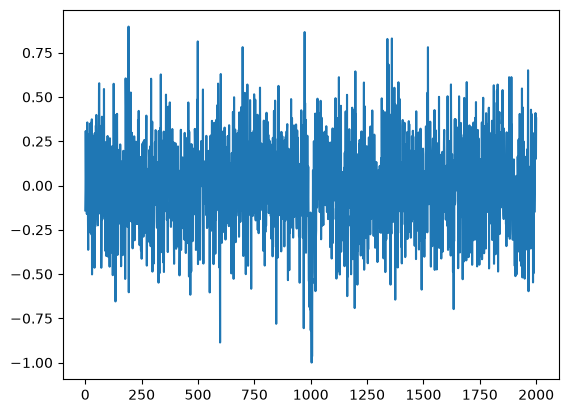

In [5]:
lc_id = 69
print("Ejemplo global:", items[lc_id]["global"].shape)
print("Ejemplo local:", items[lc_id]["local"].shape)
print("kepid:", items[lc_id]["kepid"], "|", items[lc_id]["kepler_name"])

plt.plot(items[lc_id]["global"][0])

plt.show()


### Separar las muestras en train y test

In [6]:
global_size = items[0]["global"].shape[-1]
local_size = items[0]["local"].shape[-1]
print("Tamaños - Global:", global_size, ", Local:", local_size)

split_labels = [item["label"] for item in items]
train, test = train_test_split(
    items, test_size=0.2, random_state=33, stratify=split_labels
)
val, test = train_test_split(
    test,
    test_size=0.5,
    random_state=33,
    stratify=[item["label"] for item in test],
)

train_global = torch.tensor([item["global"] for item in train], dtype=torch.float32)
train_local = torch.tensor([item["local"] for item in train], dtype=torch.float32)
train_labels = torch.tensor([item["label"] for item in train])

val_global = torch.tensor([item["global"] for item in val], dtype=torch.float32)
val_local = torch.tensor([item["local"] for item in val], dtype=torch.float32)
val_labels = torch.tensor([item["label"] for item in val])

test_global = torch.tensor([item["global"] for item in test], dtype=torch.float32)
test_local = torch.tensor([item["local"] for item in test], dtype=torch.float32)
test_labels = torch.tensor([item["label"] for item in test])

train_dataset = torch.utils.data.TensorDataset(train_global, train_local, train_labels)
val_dataset = torch.utils.data.TensorDataset(val_global, val_local, val_labels)
test_dataset = torch.utils.data.TensorDataset(test_global, test_local, test_labels)

print("Tamaño del conjunto de entrenamiento:", len(train_dataset))
print("Tamaño del conjunto de validación:", len(val_dataset))
print("Tamaño del conjunto de prueba:", len(test_dataset))
print(
    "Balance train:",
    {int(k): int((train_labels == k).sum()) for k in train_labels.unique()},
)
print(
    "Balance val:",
    {int(k): int((val_labels == k).sum()) for k in val_labels.unique()},
)


Tamaños - Global: 2001 , Local: 201
Tamaño del conjunto de entrenamiento: 5803
Tamaño del conjunto de validación: 725
Tamaño del conjunto de prueba: 726
Balance train: {0: 3673, 1: 2130}
Balance val: {0: 459, 1: 266}


C:\Users\madru\AppData\Local\Temp\ipykernel_7364\3799813135.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\b\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  train_global = torch.tensor([item["global"] for item in train], dtype=torch.float32)


## Entrenar el modelo

In [20]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets.float(), reduction='mean', pos_weight=self.pos_weight
        )
        pt = torch.exp(-bce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * bce_loss).mean()

In [25]:
batch_size = 64
num_epochs = 100
learning_rate = 0.0001
l2_penalty = 1e-4
dropout = 0.35
feature_dropout = 0.2
hidden_dim = 64
input_noise_std = 0.01
label_smoothing = 0.05
N_STACKS = 6
fraction = 1.74
print("Fracción:", fraction)
fraction = torch.tensor(fraction, device=device)
n_classes = 1

if n_classes > 1:
    loss_fn = nn.CrossEntropyLoss()
else:
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=fraction)
    # loss_fn = FocalLoss(pos_weight=fraction)

model = SpectralNHITS(
    input_size=(global_size, local_size),
    n_classes=n_classes,
    n_stacks=N_STACKS,
    hidden_dim=hidden_dim,
    dropout_prob=dropout,
    feature_dropout=feature_dropout,
    classifier_width=(64, 32),
    feature_mode="per_block",
    global_n_blocks=[1] * N_STACKS,
    local_n_blocks=[1] * N_STACKS,
).to(device)

MODEL_CKPT = f"models/SpectralNHITS_{N_STACKS}stacks_perblock.pth"
print(model.stack_summary())
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros del modelo: {n_params:,} ({n_params / 1e6:.2f} M)")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)
schedule = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

loader_kwargs = dict(num_workers=0, pin_memory=False)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)

Fracción: 1.74


ValueError: n_stacks must be 3 or 4 for defaults

In [9]:
import gc


def _smooth_binary_labels(labels: torch.Tensor, smoothing: float) -> torch.Tensor:
    if smoothing <= 0:
        return labels.float()
    return labels.float() * (1.0 - smoothing) + 0.5 * smoothing


def train_fn(
    model,
    train_loader,
    optimizer,
    loss_fn,
    max_grad_norm=1.0,
    input_noise_std=0.0,
    label_smoothing=0.0,
):
    model.train()
    train_size = len(train_loader.dataset)
    n_batches = max(len(train_loader), 1)
    total_loss = 0.0
    correct = 0
    for data in train_loader:
        global_s, local_s, labels = data
        if global_s.numel() == 0 or local_s.numel() == 0:
            continue
        if torch.isnan(global_s).any() or torch.isnan(local_s).any():
            continue
        global_s = global_s.to(device, non_blocking=False)
        local_s = local_s.to(device, non_blocking=False)
        labels = labels.to(device, non_blocking=False)
        if input_noise_std > 0:
            global_s = global_s + torch.randn_like(global_s) * input_noise_std
            local_s = local_s + torch.randn_like(local_s) * input_noise_std
        optimizer.zero_grad(set_to_none=True)
        outputs = model((global_s, local_s))
        if isinstance(loss_fn, (nn.BCEWithLogitsLoss, FocalLoss)):
            outputs = outputs.squeeze(1)
            targets = _smooth_binary_labels(labels, label_smoothing)
        else:
            targets = labels
        loss = loss_fn(outputs, targets)
        loss.backward()
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        total_loss += loss.item()
        if isinstance(loss_fn, (nn.BCEWithLogitsLoss, FocalLoss)):
            predicted = (outputs.detach() > 0.5).float()
            correct += (predicted == labels.float()).sum().item()
        else:
            _, predicted = torch.max(outputs.detach(), 1)
            correct += (predicted == labels).sum().item()
        del outputs, loss, global_s, local_s, labels
    gc.collect()
    return total_loss / n_batches, correct / train_size


def val_fn(model, val_loader, loss_fn):
    model.eval()
    val_size = len(val_loader.dataset)
    n_batches = max(len(val_loader), 1)
    total_loss = 0.0
    correct = 0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for data in val_loader:
            global_s, local_s, labels = data
            if global_s.numel() == 0 or local_s.numel() == 0:
                continue
            if torch.isnan(global_s).any() or torch.isnan(local_s).any():
                continue
            global_s = global_s.to(device, non_blocking=False)
            local_s = local_s.to(device, non_blocking=False)
            labels = labels.to(device, non_blocking=False)
            outputs = model((global_s, local_s))
            if isinstance(loss_fn, (nn.BCEWithLogitsLoss, FocalLoss)):
                outputs = outputs.squeeze(1)
                labels = labels.float()
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            if isinstance(loss_fn, (nn.BCEWithLogitsLoss, FocalLoss)):
                predicted = (outputs > 0.5).float()
            else:
                _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            del outputs, loss, global_s, local_s, labels
    gc.collect()
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_predictions, average='weighted')
    return total_loss / n_batches, correct / val_size, f1, precision, recall

In [22]:
import gc

best_val_loss = float("inf")
best_val_f1 = 0.0
patience = 12
early_stopping_counter = 0
verbose = True
loss_train_list = []
loss_val_list = []
precision_list = []
f1_list = []
recall_list = []

model.to(device).float()

for epoch in tqdm(range(num_epochs)):
    train_loss, train_accuracy = train_fn(
        model,
        train_loader,
        optimizer,
        loss_fn,
        input_noise_std=input_noise_std,
        label_smoothing=label_smoothing,
    )
    val_loss, val_accuracy, f1, precision, recall = val_fn(model, val_loader, loss_fn)
    schedule.step(val_loss)
    if verbose and (epoch % 5 == 0):
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_f1 = f1
        early_stopping_counter = 0
        os.makedirs("models", exist_ok=True)
        torch.save(model.state_dict(), MODEL_CKPT)
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"Early stopping en epoch {epoch} (mejor val_loss={best_val_loss:.4f})")
            break

    loss_train_list.append(train_loss)
    loss_val_list.append(val_loss)
    precision_list.append(precision)
    f1_list.append(f1)
    recall_list.append(recall)
    gc.collect()

if os.path.exists(MODEL_CKPT):
    model.load_state_dict(torch.load(MODEL_CKPT, map_location=device))
    print(f"Checkpoint restaurado: {MODEL_CKPT}")

print("Entrenamiento y validación completados.", "------" * 20)
print(f"Mejor val_loss: {best_val_loss:.4f}, mejor F1 val: {best_val_f1:.4f}")
print(f"Última epoch — Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

  1%|          | 1/100 [00:01<01:53,  1.14s/it]

Epoch 0/100
Train Loss: 0.0741, Train Accuracy: 0.6205
Validation Loss: 0.0740, Validation Accuracy: 0.6331
F1 Score: 0.4909, Precision: 0.4008, Recall: 0.6331


  6%|▌         | 6/100 [00:05<01:30,  1.04it/s]

Epoch 5/100
Train Loss: 0.0605, Train Accuracy: 0.6283
Validation Loss: 0.0541, Validation Accuracy: 0.6331
F1 Score: 0.4909, Precision: 0.4008, Recall: 0.6331


 11%|█         | 11/100 [00:10<01:25,  1.04it/s]

...

Epoch 25/100
Train Loss: 0.0175, Train Accuracy: 0.8575
Validation Loss: 0.0299, Validation Accuracy: 0.7766
F1 Score: 0.7752, Precision: 0.7745, Recall: 0.7766


 31%|███       | 31/100 [00:30<01:06,  1.04it/s]

Epoch 30/100
Train Loss: 0.0131, Train Accuracy: 0.8902
Validation Loss: 0.0324, Validation Accuracy: 0.7710
F1 Score: 0.7716, Precision: 0.7722, Recall: 0.7710


 35%|███▌      | 35/100 [00:34<01:04,  1.01it/s]

Epoch 35/100
Train Loss: 0.0104, Train Accuracy: 0.8987
Validation Loss: 0.0335, Validation Accuracy: 0.7876
F1 Score: 0.7882, Precision: 0.7891, Recall: 0.7876
Early stopping en epoch 35 (mejor val_loss=0.0264)
Checkpoint restaurado: models/SpectralNHITS_3stacks_perblock.pth
Entrenamiento y validación completados. ------------------------------------------------------------------------------------------------------------------------
Mejor val_loss: 0.0264, mejor F1 val: 0.8054
Última epoch — Train Acc: 0.8987, Val Acc: 0.7876


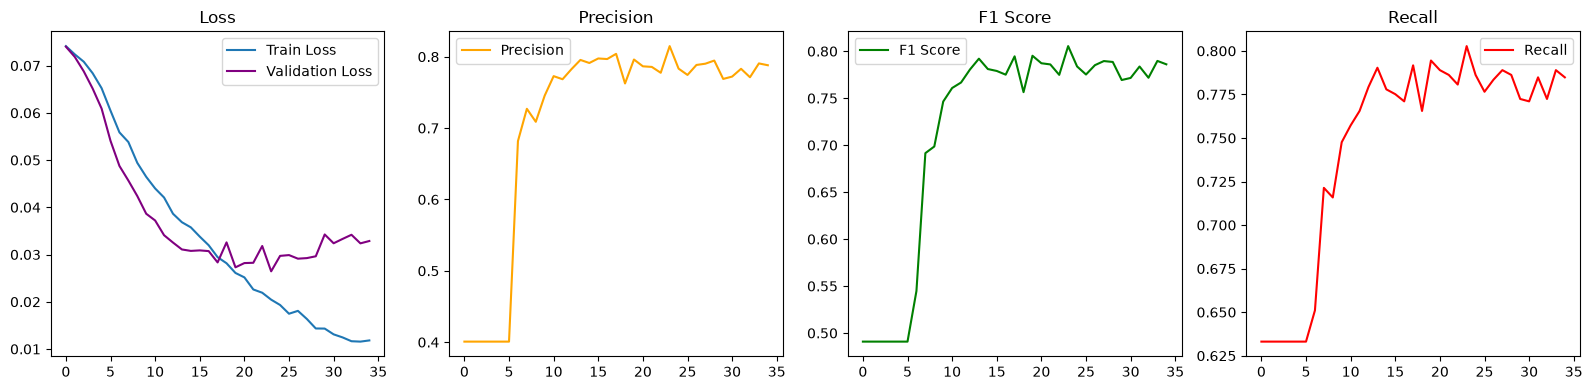

In [23]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].plot(loss_train_list, label='Train Loss')
axs[0].plot(loss_val_list, label='Validation Loss', color='purple')
axs[0].set_title('Loss')
axs[0].legend()
axs[1].plot(precision_list, label='Precision', color='orange')
axs[1].set_title('Precision')
axs[1].legend()
axs[2].plot(f1_list, label='F1 Score', color='green')
axs[2].set_title('F1 Score')
axs[2].legend()
axs[3].plot(recall_list, label='Recall', color='red')
axs[3].set_title('Recall')
axs[3].legend()
plt.tight_layout()
plt.show()

## Evaluación en test

In [24]:
def predict(model, data_loader, loss_fn):
    predicted, probs, labels, loss_test = [], [], [], []
    model.eval()
    with torch.no_grad():
        for data in data_loader:
            global_s, local_s, label = data
            if global_s.numel() == 0 or local_s.numel() == 0:
                continue
            if torch.isnan(global_s).any() or torch.isnan(local_s).any():
                continue
            global_s = global_s.to(device)
            local_s = local_s.to(device)
            label = label.to(device)
            output = model((global_s, local_s))
            if isinstance(loss_fn, (nn.BCEWithLogitsLoss, FocalLoss)):
                output = output.squeeze(1)
                label = label.float()
                prob = torch.sigmoid(output)
                pred = (prob > 0.5).float()
            else:
                prob = F.softmax(output, dim=1)
                _, pred = torch.max(output, 1)
            loss = loss_fn(output, label)
            predicted.extend(pred.cpu().numpy())
            probs.extend(prob.cpu().numpy())
            labels.extend(label.cpu().numpy())
            loss_test.append(loss.item())
    return np.array(predicted), np.array(labels), np.array(probs), np.array(loss_test)

model.load_state_dict(torch.load(MODEL_CKPT, map_location=device))
predicted, labels, probs, loss_serie = predict(model, test_loader, loss_fn)
print('Test F1:', f1_score(labels, predicted, average='weighted'))
print('Test Precision:', precision_score(labels, predicted, average='weighted', zero_division=0))
print('Test Recall:', recall_score(labels, predicted, average='weighted'))
print('Test Loss (mean):', np.nanmean(loss_serie))

Test F1: 0.7574937500642581
Test Precision: 0.7735233568761012
Test Recall: 0.7534435261707989
Test Loss (mean): 0.03368082952996095


## Evaluación 22 vs 25 (candidatos)

Entrena con etiquetas **2022** (CONFIRMED / FALSE POSITIVE) y predice sobre los **CANDIDATE de 2022**. La precisión real se mide contra la disposición **2025** (`koi_class` en el `.npz`) en los candidatos cuya clase cambió entre catálogos.

In [13]:
candidate_items = []

for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Loading candidates"):
    sample = load_npz(NPZ_DIR / row["file"])
    kepid = sample["kepid"]
    kepler_name = sample["kepler_name"]
    key = (kepid, kepler_name)

    if key in labels_2022:
        class_2022 = labels_2022[key]
    elif kepler_name in labels_2022:
        class_2022 = labels_2022[kepler_name]
    else:
        continue

    if class_2022 != "CANDIDATE":
        continue

    global_arr, local_arr = level0_sample_arrays(sample)
    candidate_items.append(
        {
            "global": global_arr,
            "local": local_arr,
            "kepid": kepid,
            "kepler_name": kepler_name,
            "class_2022": class_2022,
            "class_2025": sample["koi_class"],
        }
    )

print(f"Candidatos 2022: {len(candidate_items)}")

cand_global = torch.tensor([x["global"] for x in candidate_items], dtype=torch.float32)
cand_local = torch.tensor([x["local"] for x in candidate_items], dtype=torch.float32)
cand_labels = torch.zeros(len(candidate_items))  # placeholder para TensorDataset
candidates_dataset = torch.utils.data.TensorDataset(cand_global, cand_local, cand_labels)
candidates_loader = DataLoader(
    candidates_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)

model.load_state_dict(torch.load(MODEL_CKPT, map_location=device))
predicted_candidates, _, probs, _ = predict(model, candidates_loader, loss_fn)
print(f"Predicciones generadas: {len(predicted_candidates)}")

Loading candidates: 100%|██████████| 9298/9298 [00:04<00:00, 1876.75it/s]


Candidatos 2022: 2044
Predicciones generadas: 2044


In [14]:
os.makedirs("results", exist_ok=True)

df_results = pd.DataFrame(
    {
        "id": [f"candidate_{i + 1}" for i in range(len(predicted_candidates))],
        "kepler_name": [x["kepler_name"] for x in candidate_items],
        "kepid": [x["kepid"] for x in candidate_items],
        "predicted_2022": predicted_candidates,
        "class_2022": [x["class_2022"] for x in candidate_items],
        "class_2025": [x["class_2025"] for x in candidate_items],
        "probability": probs,
    }
)

out_csv = "results/candidates_predictions_SpectralNHITS_2022_vs_2025.csv"
df_results.to_csv(out_csv, index=False)
print(f"Resultados guardados en '{out_csv}'.")

n_positive = int(predicted_candidates.sum())
n_negative = len(predicted_candidates) - n_positive
print("Predichos como CONFIRMED:", n_positive)
print("Predichos como FALSE POSITIVE:", n_negative)

Resultados guardados en 'results/candidates_predictions_SpectralNHITS_2022_vs_2025.csv'.
Predichos como CONFIRMED: 1172
Predichos como FALSE POSITIVE: 872


In [15]:
changed_candidates_df = pd.read_csv("results/changed_candidates.csv")
print("Candidatos con cambio de clase (referencia):", changed_candidates_df.shape[0])

changed_candidates = df_results[
    df_results["kepler_name"].isin(changed_candidates_df["kepoi_name"])
].copy()

changed_candidates["error"] = changed_candidates.apply(
    lambda row: int(
        (row["predicted_2022"] == 1 and row["class_2025"] == "FALSE POSITIVE")
        or (row["predicted_2022"] == 0 and row["class_2025"] == "CONFIRMED")
    ),
    axis=1,
)

print("Candidatos que cambiaron entre 2022 y 2025:", len(changed_candidates))
if len(changed_candidates) > 0:
    error_rate = changed_candidates["error"].mean() * 100
    accuracy = (1 - changed_candidates["error"].mean()) * 100
    print(f"Tasa de error (predicción vs 2025): {error_rate:.2f}%")
    print(f"Acierto en cambios de clase: {accuracy:.2f}%")
    display(changed_candidates.head(10))

changed_candidates.to_csv(
    "results/changed_candidates_SpectralNHITS_2022_vs_2025.csv", index=False
)

Candidatos con cambio de clase (referencia): 77
Candidatos que cambiaron entre 2022 y 2025: 77
Tasa de error (predicción vs 2025): 28.57%
Acierto en cambios de clase: 71.43%


,id,kepler_name,kepid,predicted_2022,class_2022,class_2025,probability,error
16,candidate_17,K01608.03,10055126,0.0,CANDIDATE,CONFIRMED,0.444999,1
34,candidate_35,K01082.01,10141900,1.0,CANDIDATE,CONFIRMED,0.870259,0
35,candidate_36,K01082.02,10141900,1.0,CANDIDATE,CONFIRMED,0.887563,0
47,candidate_48,K00427.01,10189546,1.0,CANDIDATE,CONFIRMED,0.861721,0
64,candidate_65,K00732.03,10265898,1.0,CANDIDATE,CONFIRMED,0.661643,0
81,candidate_82,K01175.02,10350571,1.0,CANDIDATE,CONFIRMED,0.829019,0
85,candidate_86,K02583.01,10387742,1.0,CANDIDATE,CONFIRMED,0.922947,0
103,candidate_104,K00474.03,10460984,1.0,CANDIDATE,CONFIRMED,0.817666,0
154,candidate_155,K07368.01,10736489,1.0,CANDIDATE,CONFIRMED,0.827416,0
177,candidate_178,K07378.01,10843431,0.0,CANDIDATE,CONFIRMED,0.480868,1
